<a href="https://colab.research.google.com/github/guilhermemoraes-lasalle/ColecoesEassociacoes/blob/main/Exercicio_Pratico_2_Ecommerce_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Prático 2 — Análise de Desempenho e Limpeza de Dados de E-commerce

Este notebook realiza a limpeza, preparação e análise visual de uma base fictícia de transações de e-commerce.

**Etapas:**
1. Criação do dataset com valores nulos e duplicatas.
2. Limpeza e preparação dos dados.
3. Comparação do valor gasto entre categorias com Boxplot.
4. Identificação de variação e outliers.
5. Análise da distribuição da idade dos clientes com histograma e KDE.


## 1. Configuração do ambiente e criação dos dados


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
np.random.seed(101)

# Gerando dados fictícios de clientes de um e-commerce
n = 200
categorias = ['Eletrônicos', 'Vestuário', 'Casa e Decoração', 'Livros']

dados = {
    'ID_Cliente': np.random.randint(1000, 1050, size=n),
    'Categoria': np.random.choice(categorias, size=n),
    'Valor_Gasto': np.random.normal(loc=250, scale=80, size=n).round(2),
    'Avaliacao_Compra': np.random.choice(
        [1, 2, 3, 4, 5, np.nan],
        size=n,
        p=[0.1, 0.1, 0.2, 0.3, 0.2, 0.1]
    ),
    'Idade_Cliente': np.random.randint(18, 65, size=n)
}

df_ecommerce = pd.DataFrame(dados)

# Inserindo algumas linhas duplicadas intencionalmente
df_ecommerce = pd.concat(
    [df_ecommerce, df_ecommerce.iloc[:10]],
    ignore_index=True
)

print("Dataset gerado com sucesso!")
print(f"Total de linhas no dataset: {len(df_ecommerce)}")

df_ecommerce.head()


Dataset gerado com sucesso!
Total de linhas no dataset: 210


,ID_Cliente,Categoria,Valor_Gasto,Avaliacao_Compra,Idade_Cliente
0,1031,Vestuário,236.62,NaN,33
1,1011,Eletrônicos,190.28,4.0,47
2,1017,Eletrônicos,336.59,2.0,35
3,1006,Eletrônicos,307.38,5.0,52
4,1023,Vestuário,170.69,4.0,42


## 2. Tarefa 1 — Limpeza e preparação dos dados


In [2]:
# Verificando a quantidade de linhas duplicadas
quantidade_duplicadas = df_ecommerce.duplicated().sum()

print("Quantidade de linhas duplicadas:", quantidade_duplicadas)


Quantidade de linhas duplicadas: 10


In [3]:
# Removendo as linhas duplicadas
df_ecommerce = df_ecommerce.drop_duplicates().copy()

print("Total de linhas após remover duplicatas:", len(df_ecommerce))


Total de linhas após remover duplicatas: 200


In [4]:
# Identificando valores nulos por coluna
print("Valores nulos por coluna:")
df_ecommerce.isnull().sum()


Valores nulos por coluna:


,0
ID_Cliente,0
Categoria,0
Valor_Gasto,0
Avaliacao_Compra,21
Idade_Cliente,0


In [5]:
# Calculando a mediana da coluna Avaliacao_Compra
mediana_avaliacao = df_ecommerce['Avaliacao_Compra'].median()

print("Mediana da avaliação:", mediana_avaliacao)

# Preenchendo os valores nulos com a mediana
df_ecommerce['Avaliacao_Compra'] = (
    df_ecommerce['Avaliacao_Compra']
    .fillna(mediana_avaliacao)
)

print("\nValores nulos após o tratamento:")
df_ecommerce.isnull().sum()


Mediana da avaliação: 4.0

Valores nulos após o tratamento:


,0
ID_Cliente,0
Categoria,0
Valor_Gasto,0
Avaliacao_Compra,0
Idade_Cliente,0


### Resultado da limpeza

Após a remoção das duplicatas, o DataFrame volta a possuir os 200 registros originais. Os valores ausentes da coluna `Avaliacao_Compra` são substituídos pela mediana, evitando a exclusão desnecessária de registros.


## 3. Tarefa 2 — Comparação do valor gasto por categoria


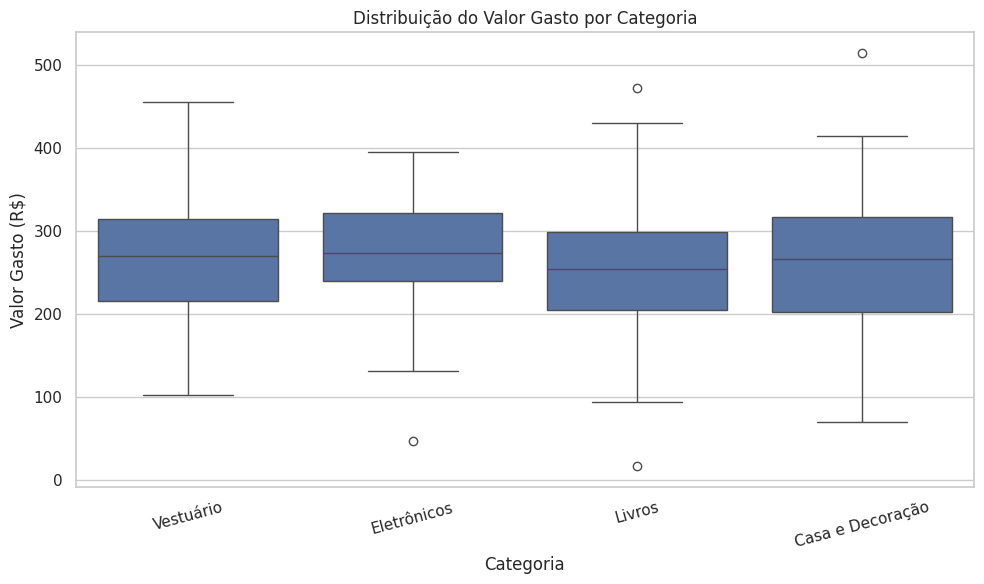

In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_ecommerce,
    x='Categoria',
    y='Valor_Gasto'
)

plt.title('Distribuição do Valor Gasto por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Valor Gasto (R$)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Análise da variação entre as categorias


In [7]:
variacao_categoria = (
    df_ecommerce
    .groupby('Categoria')['Valor_Gasto']
    .agg(['std', 'min', 'max'])
)

variacao_categoria['amplitude'] = (
    variacao_categoria['max'] - variacao_categoria['min']
)

variacao_categoria.sort_values('std', ascending=False)


,std,min,max,amplitude
Categoria,,,,
Casa e Decoração,88.942519,70.63,514.29,443.66
Livros,81.135752,16.89,471.64,454.75
Vestuário,77.837054,102.12,455.23,353.11
Eletrônicos,71.303618,47.76,395.03,347.27


In [8]:
categoria_maior_variacao = variacao_categoria['std'].idxmax()

print(
    "Categoria com maior variação pelo desvio padrão:",
    categoria_maior_variacao
)


Categoria com maior variação pelo desvio padrão: Casa e Decoração


### Identificação de outliers pelo método IQR


In [9]:
def contar_outliers(grupo):
    q1 = grupo.quantile(0.25)
    q3 = grupo.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    return (
        (grupo < limite_inferior) |
        (grupo > limite_superior)
    ).sum()


outliers_categoria = (
    df_ecommerce
    .groupby('Categoria')['Valor_Gasto']
    .apply(contar_outliers)
    .sort_values(ascending=False)
)

print("Quantidade de outliers por categoria:")
print(outliers_categoria)

print(
    "\nCategoria com maior presença de outliers:",
    outliers_categoria.idxmax()
)


Quantidade de outliers por categoria:
Categoria
Livros              2
Casa e Decoração    1
Eletrônicos         1
Vestuário           0
Name: Valor_Gasto, dtype: int64

Categoria com maior presença de outliers: Livros


## 4. Tarefa 3 — Distribuição da idade dos clientes


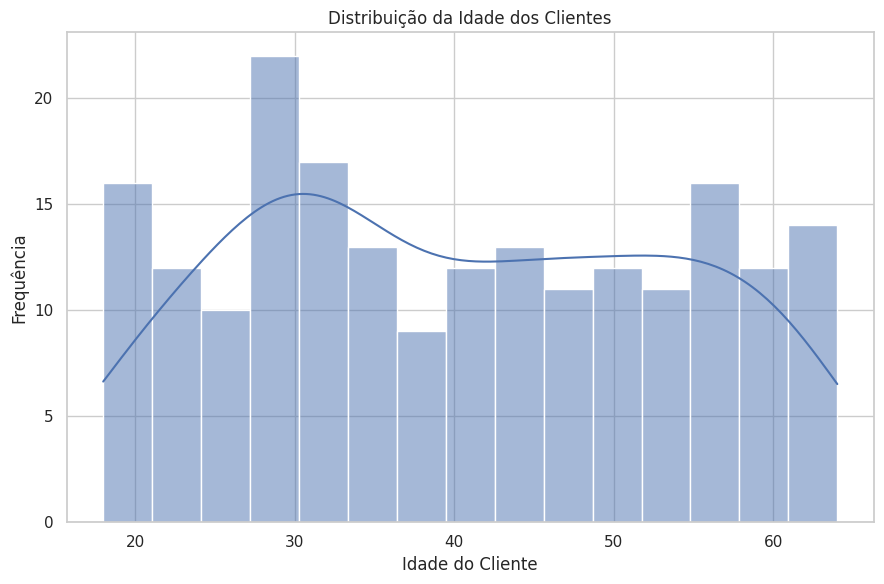

In [10]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df_ecommerce,
    x='Idade_Cliente',
    kde=True,
    bins=15
)

plt.title('Distribuição da Idade dos Clientes')
plt.xlabel('Idade do Cliente')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


## 5. Visualização dos dados tratados


In [11]:
df_ecommerce.head(10)


,ID_Cliente,Categoria,Valor_Gasto,Avaliacao_Compra,Idade_Cliente
0,1031,Vestuário,236.62,4.0,33
1,1011,Eletrônicos,190.28,4.0,47
2,1017,Eletrônicos,336.59,2.0,35
3,1006,Eletrônicos,307.38,5.0,52
4,1023,Vestuário,170.69,4.0,42
5,1011,Livros,254.00,4.0,41
6,1047,Vestuário,102.12,4.0,64
7,1009,Casa e Decoração,140.96,2.0,43
8,1013,Casa e Decoração,286.96,4.0,18
9,1040,Livros,185.87,1.0,44


## 6. Exportação opcional da base limpa


In [12]:
df_ecommerce.to_csv(
    'ecommerce_limpo.csv',
    index=False
)

print("Arquivo ecommerce_limpo.csv criado com sucesso!")


Arquivo ecommerce_limpo.csv criado com sucesso!


## Conclusão

A análise realizou o tratamento dos principais problemas presentes na base, removendo registros duplicados e preenchendo avaliações ausentes com a mediana. O Boxplot permite comparar a dispersão do valor gasto entre as categorias e identificar possíveis outliers, enquanto o histograma com KDE apresenta a distribuição etária dos clientes.
